# CHT.M1 - Protein Data Acquisition from Protein Data Bank
### Notebook 05. Protein Data Acquisition

**Version 1.0 - June, 2026. Monterrey**

**Author:** [Fernanda I. Saldívar González](https://orcid.org/0000-0002-0435-8662). Tecnológico de Monterrey.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NanoBiostructuresRG/CheminformaticsTutorial/blob/main/modules/m1_data_acquisition/notebooks/05_protein_data_acquisition_from_PDB.ipynb)



### Contents
This notebook introduces the process of retrieving, analyzing, and visualizing protein structures from the Protein Data Bank (PDB) using widely adopted Python libraries for structural bioinformatics and cheminformatics.

The activities are structured to guide you through the complete workflow of:

* Understanding the organization and content of the Protein Data Bank.
* Searching and retrieving protein structures programmatically.
* Accessing and manipulating structural data using `Biotite` and `BioPython` packages.
* Generating interactive three-dimensional visualizations using `Py3Dmol`
* Identifying key criteria for target selection, including structure quality, ligand availability, resolution, and biological relevance.
* Evaluating protein structures for molecular docking applications.


This notebook is designed to be completed in approximately 60–120 minutes.

You are encouraged to explore different protein targets, compare multiple structures of the same protein, and experiment with visualization options. The goal is not only to retrieve and display protein structures, but also to develop a practical understanding of how structural biology data can be accessed, analyzed, and selected for computational studies such as molecular docking.

### How to work

1. **Open the notebook**: Click on the "Open in Colab" button or use the link provided to open the tutorial in **Google Colab**.
2. **Create your workspace**: Once open, go to **File > Save a copy in Drive**. This is vital! You must work on your own copy to ensure your progress is saved.
    - **Tip**: Look at the top-left corner. If you see "Copy of...", you are ready to go!
3. **Solve the exercises**: Complete the missing parts of the code where indicated. You can run each cell to test your progress (Shift + Enter).
4. When you finish:
    - **Rename** your file following the convention:
        - `YourID_NB5_M1.ipynb`
    - **Download the file**: Go to File > Download > Download .ipynb.
    - **Upload** the downloaded file to the **CANVAS assignment module**.

>**NOTE:** **Do not** modify the notebook structure or function signatures unless explicitly stated.


---

# Protein Data Bank (PDB)

The [Protein Data Bank (PDB)](https://www.rcsb.org/) is an open-access repository that stores structural information on proteins, nucleic acids, and other biological macromolecules, along with scientific data derived from structural biology research. Over the years, the PDB has become an essential resource in fields such as structural biology, structural genomics, and structure-based drug design.

When searching for a protein of interest, users can perform either basic or advanced searches to obtain accurate and comprehensive information. The PDB provides detailed data about a selected protein, including its two-dimensional (2D) and three-dimensional (3D) structures, annotations of important structural regions, the full protein name, and the source organism from which it was obtained. Additionally, the database allows users to identify structurally similar proteins and explore the chemical and physical properties of biomolecular structures. Information regarding the experimental methods used to determine the structures is also available, with X-ray crystallography and nuclear magnetic resonance (NMR) spectroscopy being among the most common techniques.

In structure-based drug design, protein structures are widely used for molecular docking studies and for the de novo design of novel bioactive compounds.

When selecting protein structures for molecular docking studies, several criteria should be considered to ensure the quality and reliability of the chosen target:

* Prefer high-resolution structures whenever available; ideally, the resolution should be better than 2.5 Å.
* Consider the experimental method used to determine the structure, with X-ray diffraction generally being the preferred technique.
* Confirm that the domain or region of interest is present in the selected structure.
* Consider the publication date and, when possible, prioritize recently published structures.
* Verify the source organism from which the protein was obtained.
* Depending on the study objectives, determine whether the structure corresponds to a wild-type protein, a mutant, or a specific variant.
* Assess the completeness of side chains and other structural elements. Structures solved using older experimental techniques may occasionally contain missing side chains due to technological limitations or manual modeling errors.
* Verify the presence of a co-crystallized ligand, as this can provide valuable information about the binding site.
* Structural information can be used to infer the molecular and physicochemical requirements necessary for small molecules to bind effectively to the target protein.

Careful evaluation of these criteria can significantly improve the reliability of molecular docking results and subsequent structure-based drug design efforts.

---

### Step 0: The Computational Environment

Before retrieving and analyzing protein structures, we must load our specialized toolkit. In this module, we rely on a collection of libraries designed for structural bioinformatics, molecular representation, and three-dimensional visualization.

* **`pypdb`**: A Python interface for accessing the Protein Data Bank (PDB). It allows us to search, retrieve, and query structural information programmatically without manually navigating the PDB website.
* **`biotite`**: A comprehensive bioinformatics library for working with biological sequences and macromolecular structures. It provides efficient tools for downloading, parsing, manipulating, and analyzing protein structure files.
* **`py3Dmol`**: An interactive molecular visualization library that enables high-quality 3D rendering of proteins, ligands, and biomolecular complexes directly within Jupyter notebooks.
requests_cache: A utility that stores previously downloaded web responses locally, reducing redundant requests to online databases and improving workflow efficiency.

In [ ]:
!pip install requests_cache
!pip install biotite
!pip install pypdb
!pip install py3Dmol

In [ ]:
import collections
import logging
import pathlib
import warnings
import datetime
from datetime import datetime, UTC
import time
import requests
import requests_cache
import pypdb
import biotite.database.rcsb as rcsb
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Cache requests -- this will speed up repeated queries to PDB
requests_cache.install_cache("rcsb_pdb", backend="memory")

### Step 1: Search Protein Structures Using a Single Criterion

In this example, we use the RCSB Search API to identify protein structures that satisfy a single search criterion. Applying individual filters allows researchers to explore the contents of the Protein Data Bank (PDB) and understand how specific metadata fields, such as deposition date, experimental method, organism, or resolution, can be used to retrieve relevant structures.

The following query searches for all structures deposited after a specified date and returns the total number of matching entries in the PDB.


In [ ]:
#Protein Structures by Deposition Date

after_deposition_date = datetime(2020, 1, 1, tzinfo=UTC).isoformat().replace("+00:00", "Z")

query_by_deposition_date = rcsb.FieldQuery(
    "rcsb_accession_info.deposit_date",
    greater=after_deposition_date,
)

print(
    f"Number of structures deposited after {after_deposition_date}: "
    f"{rcsb.count(query_by_deposition_date)}"
)

In [ ]:
#Protein Structures by Experimental Method
experimental_method = "X-RAY DIFFRACTION"

query_by_experimental_method = rcsb.FieldQuery("exptl.method", exact_match=experimental_method)

print(
    f"Number of structures resolved by {experimental_method}: {rcsb.count(query_by_experimental_method)}"
)

time.sleep(0.1)

In [ ]:
#Protein Structures by Resolution
max_resolution = 2.5

query_by_resolution = rcsb.FieldQuery(
    "rcsb_entry_info.resolution_combined", less_or_equal=max_resolution
)

print(
    f"Number of structures with resolution less than or equal to {max_resolution}: {rcsb.count(query_by_resolution)}"
)

time.sleep(0.1)

In [ ]:
#Protein Structures by Number of Chains
n_chains = 1

query_by_polymer_count = rcsb.FieldQuery(
    "rcsb_entry_info.deposited_polymer_entity_instance_count", equals=n_chains
)

print(
    f"Number of structures with only {n_chains} chain: {rcsb.count(query_by_polymer_count)}"
)

time.sleep(0.1)

In [ ]:
#Protein Structures by Co-Crystallized Ligand Presence
min_ligand_molecular_weight = 100.0

query_by_ligand_mw = rcsb.FieldQuery(
    "chem_comp.formula_weight", molecular_definition=True, greater=min_ligand_molecular_weight
)

print(
    f"Number of structures with ligand of more than or equal to {min_ligand_molecular_weight} Da: {rcsb.count(query_by_ligand_mw)}"
)

time.sleep(0.1)

In [ ]:
#Protein Structures by Organism
query_by_organism = rcsb.FieldQuery(
    "rcsb_entity_source_organism.scientific_name", exact_match="Homo sapiens"
)

print( f"Number of structures from Homo sapiens: " f"{rcsb.count(query_by_organism)}"
)

time.sleep(0.1)

In [ ]:
#Protein Structures by Uniprot ID
uniprot_id = "P37231" #PPARg

query_by_uniprot_id = rcsb.FieldQuery(
    "rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession",
    exact_match=uniprot_id,
)

print(
    f"Number of PDB structures associated with UniProt ID {uniprot_id}: "
    f"{rcsb.count(query_by_uniprot_id)}"
)

time.sleep(0.1)

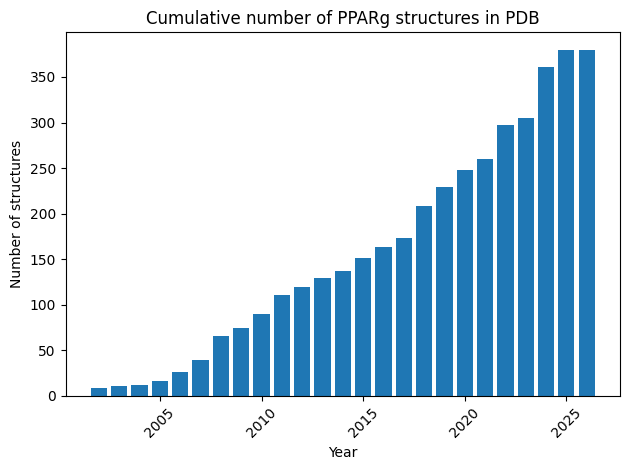

In [ ]:
#Visualize cumulative number of PPARg structures in PDB
years = range(2002, datetime.now().year + 1)
n_structures = []
for year in years:
    # Set latest date for allowed deposition
    before_deposition_date = f"{year}-12-31T23:59:59Z"
    # Set up query for structures deposited latest at given date
    query_by_deposition_date2 = rcsb.FieldQuery(
        "rcsb_accession_info.deposit_date", less_or_equal=before_deposition_date
    )
    # Set up combined query
    query = rcsb.CompositeQuery(
        [query_by_uniprot_id, query_by_deposition_date2],
        "and",
    )
    # Count matching structures and add to list
    n_structures.append(rcsb.count(query))
    # wait shortly to not overload the API
    time.sleep(0.1)

plt.figure()
plt.bar(years, n_structures)

plt.xlabel("Year")
plt.ylabel("Number of structures")
plt.title("Cumulative number of PPARg structures in PDB")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---

### Step 2: Combining Multiple Search Criteria (Compound Queries)

The rcsb.search() function provides a more flexible and explicit way to query the Protein Data Bank (PDB). Unlike simpler counting queries, this function requires a more detailed specification of the desired search criteria and returns the actual matching entries, not only their count.

This approach is more powerful but also more labor-intensive, since the user must clearly define the target fields and conditions for filtering the dataset.

A key aspect of rcsb.search() is the use of logical operators to refine results and exclude unwanted data:

* **`|` (OR)**: returns entries that satisfy at least one of the conditions
* **`&` (AND)**: returns entries that satisfy all conditions simultaneously
* **`^` (XOR)**: returns entries that satisfy only one of the conditions, but not both

This makes rcsb.search() particularly useful when building high-quality datasets for structural bioinformatics applications, where precise filtering is essential.



In [ ]:
composite_query = query_by_uniprot_id & ~query_by_deposition_date

print(rcsb.search(composite_query))
print(rcsb.count(composite_query))

The **rcsb.CompositeQuery** function allows multiple search conditions to be combined into a single, unified query. It acts as a compact filtering mechanism, enabling users to define complex selection criteria without building each condition separately.


In [ ]:
composite_query_2=  rcsb.CompositeQuery(
    [
        query_by_uniprot_id,
        query_by_deposition_date,
        query_by_experimental_method,
        query_by_resolution,
        query_by_organism,
        query_by_ligand_mw,
    ],
    "and",
)
pdb_ids = rcsb.search(composite_query_2)
print(f"Number of matches: {len(pdb_ids)}")
print("Selected PDB IDs:")
print(*pdb_ids)

---


# Protein Visualization

This section focuses on the visualization of a protein structure using different software packages designed for the presentation and analysis of macromolecular systems.





### Step 0: The Computational Environment

First, it is necessary to install the required packages that will support this workflow:

* **`Bio.PDB`**: A module specialized in handling and analyzing three-dimensional structures of biological macromolecules, particularly those obtained from crystallographic data.

* **`nglview`**: An interactive visualization tool for molecular structures and trajectories, commonly used within Jupyter notebooks.

* **`ipywidgets`**: Provides interactive user interface components that allow event handling and dynamic interaction within the notebook environment.

* **`Biopython`**: A widely used library for bioinformatics, supporting both software development and routine scripting tasks for biological data analysis.

* **`py3Dmol`**: A library for the visualization of molecular systems in three dimensions, enabling high-quality rendering directly in notebooks.

Note: ensure that the protein structure file of interest is available and uploaded in the working environment, as it will be required for proper visualization.

In [ ]:
!pip install Bio
!pip install nglview
!pip install ipywidgets
!pip install py3Dmol

In [ ]:
from Bio.PDB import *
import nglview as nv
import ipywidgets
import py3Dmol
from Bio.PDB import PDBParser, PDBIO
import io


### Step 1. Protein Visualization Styles
In this exercise, a protein structure (7AWC.pdb) is loaded using Biopython and visualized interactively with nglview. The structure is then processed to separate each chain, saving them as individual PDB files using the PDBIO module. This allows for easier analysis of specific chains in downstream applications.

In [ ]:
pdb_parser = PDBParser()
structure = pdb_parser.get_structure("7AWC", "7AWC.pdb")
view = nv.show_biopython(structure)
#This will separate each chain into its own PDB file
io = PDBIO()
for chain in structure.get_chains():
    io.set_structure(chain)
    io.save(f"/content/7AWC_chain{chain.get_id()}.pdb")

In [ ]:
#Open Chain A
with open("/content/7AWC_chainA.pdb") as ifile:
    system = "".join([x for x in ifile])

In [ ]:
# Visualize chain A of the protein using a cartoon representation colored by spectrum
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(system)
view.setStyle({'model': -1}, {"cartoon": {'color': 'spectrum'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# Apply a stick representation with a green carbon color scheme
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(system)
view.setStyle({'model': -1}, {"stick":{'colorscheme':'greenCarbon'}},viewer=(1,0))
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#Visualize the protein using a cartoon representation with arrows and tubes
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(system)
view.setStyle({'model': -1}, {'cartoon':{'arrows':True, 'tubes':True, 'style':'oval', 'color':'white'}},viewer=(0,1))
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# Visualize the protein with cartoon and stick representations, enabling interactive atom labels.

v = py3Dmol.view(query="pdb:7awc",style={'cartoon':{},'stick':{}})
v.setHoverable({},True,'''function(atom,viewer,event,container) {
                   if(!atom.label) {
                    atom.label = viewer.addLabel(atom.resn+":"+atom.atom,{position: atom, backgroundColor: 'mintcream', fontColor:'black'});
                   }}''',
               '''function(atom,viewer) {
                   if(atom.label) {
                    viewer.removeLabel(atom.label);
                    delete atom.label;
                   }
                }''')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

To conclude this visualization section, the protein was examined in its different representations.


In [ ]:
view = py3Dmol.view(query='pdb:7awc',viewergrid=(2,2),style=[[{'sphere':{}},{'cartoon':{'arrows':True, 'tubes':True, 'style':'oval', 'color':'white'}}],
                                                            [{'stick':{'colorscheme':'greenCarbon'}},{'cartoon':{'color':'spectrum'}}]])
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Add protein surface visualization colored by B-factor


In [ ]:
view = py3Dmol.view(query='pdb:7awc')
view.setStyle({'cartoon': {'color':'white'}})
view.addSurface(py3Dmol.VDW,{'opacity':0.6,'colorscheme':{'prop':'b','gradient':'sinebow','min':0,'max':70}})

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 2. Identify and visualize the co-crystallized ligand in the protein structure


In [ ]:
#Identify the co-crystallized ligand (rosiglitazone, BRL) in the protein structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("7AWC", "7AWC_chainA.pdb")

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.id[0] != " ":
                print("Ligand found:", residue.get_resname(), residue.get_id())

In [ ]:
## Extract the co-crystallized ligand (rosiglitazone, BRL) from the protein structure and save it as a separate PDB file

parser = PDBParser(QUIET=True)
structure = parser.get_structure("7AWC", "7AWC_chainA.pdb")

io = PDBIO()

class SelectRosiglitazone:
    def accept_model(self, model):
        return True

    def accept_chain(self, chain):
        return True

    def accept_residue(self, residue):
        resname = residue.get_resname()

        # Select rosiglitazone (BRL)
        return resname == "BRL"

    def accept_atom(self, atom):
        return True

io.set_structure(structure)
io.save("7AWC_ligand.pdb", SelectRosiglitazone())

In [ ]:
# Visualize the extracted ligand (rosiglitazone) using a stick representation with a green carbon color scheme

ligand = open("/content/7AWC_ligand.pdb", 'r').read()
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(ligand)
view.setStyle({'model': -1}, {"stick":{'colorscheme':'greenCarbon'}},viewer=(1,0))
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#Open protein structure
protein = open("/content/7AWC_chainA.pdb", 'r').read()

In [ ]:
#Visualize the protein–ligand complex
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(protein)
view.setStyle({'cartoon': {'color':'white'}})
view.addSurface(py3Dmol.VDW,{'opacity':0.5,'colorscheme':{'prop':'b','gradient':'sinebow','min':0,'max':70}})
view.addModelsAsFrames(ligand)
view.setStyle({'model': -1}, {"stick":{'colorscheme':'greenCarbon'}},viewer=(1,0))
view.zoomTo()
view.show()

resid_hover = """function(atom,viewer) {{
    if(!atom.label) {{
        atom.label = viewer.addLabel('{0}:'+atom.atom+atom.serial,
            {{position: atom, backgroundColor: 'mintcream', fontColor:'black'}});
    }}
}}"""
hover_func = """
function(atom,viewer) {
    if(!atom.label) {
        atom.label = viewer.addLabel(atom.interaction,
            {position: atom, backgroundColor: 'black', fontColor:'white'});
    }
}"""
unhover_func = """
function(atom,viewer) {
    if(atom.label) {
        viewer.removeLabel(atom.label);
        delete atom.label;
    }
}"""

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### License  
The content of this tutorial itself is licensed under the terms and conditions of the [Creative Commons Attribution (CC BY 4.0) license](https://creativecommons.org/licenses/by/4.0/legalcode.en), and the underlying source code used to format and display that content is licensed under the [MIT license](https://github.com/NanoBiostructuresRG/CheminformaticsTutorial/blob/main/LICENSE). See the LICENSE files for full details.

### Attribution
If you use or adapt this material, please provide appropriate credit to the original [authors](https://orcid.org/0000-0002-0435-8662) and repository:
[https://github.com/NanoBiostructuresRG](https://github.com/NanoBiostructuresRG)